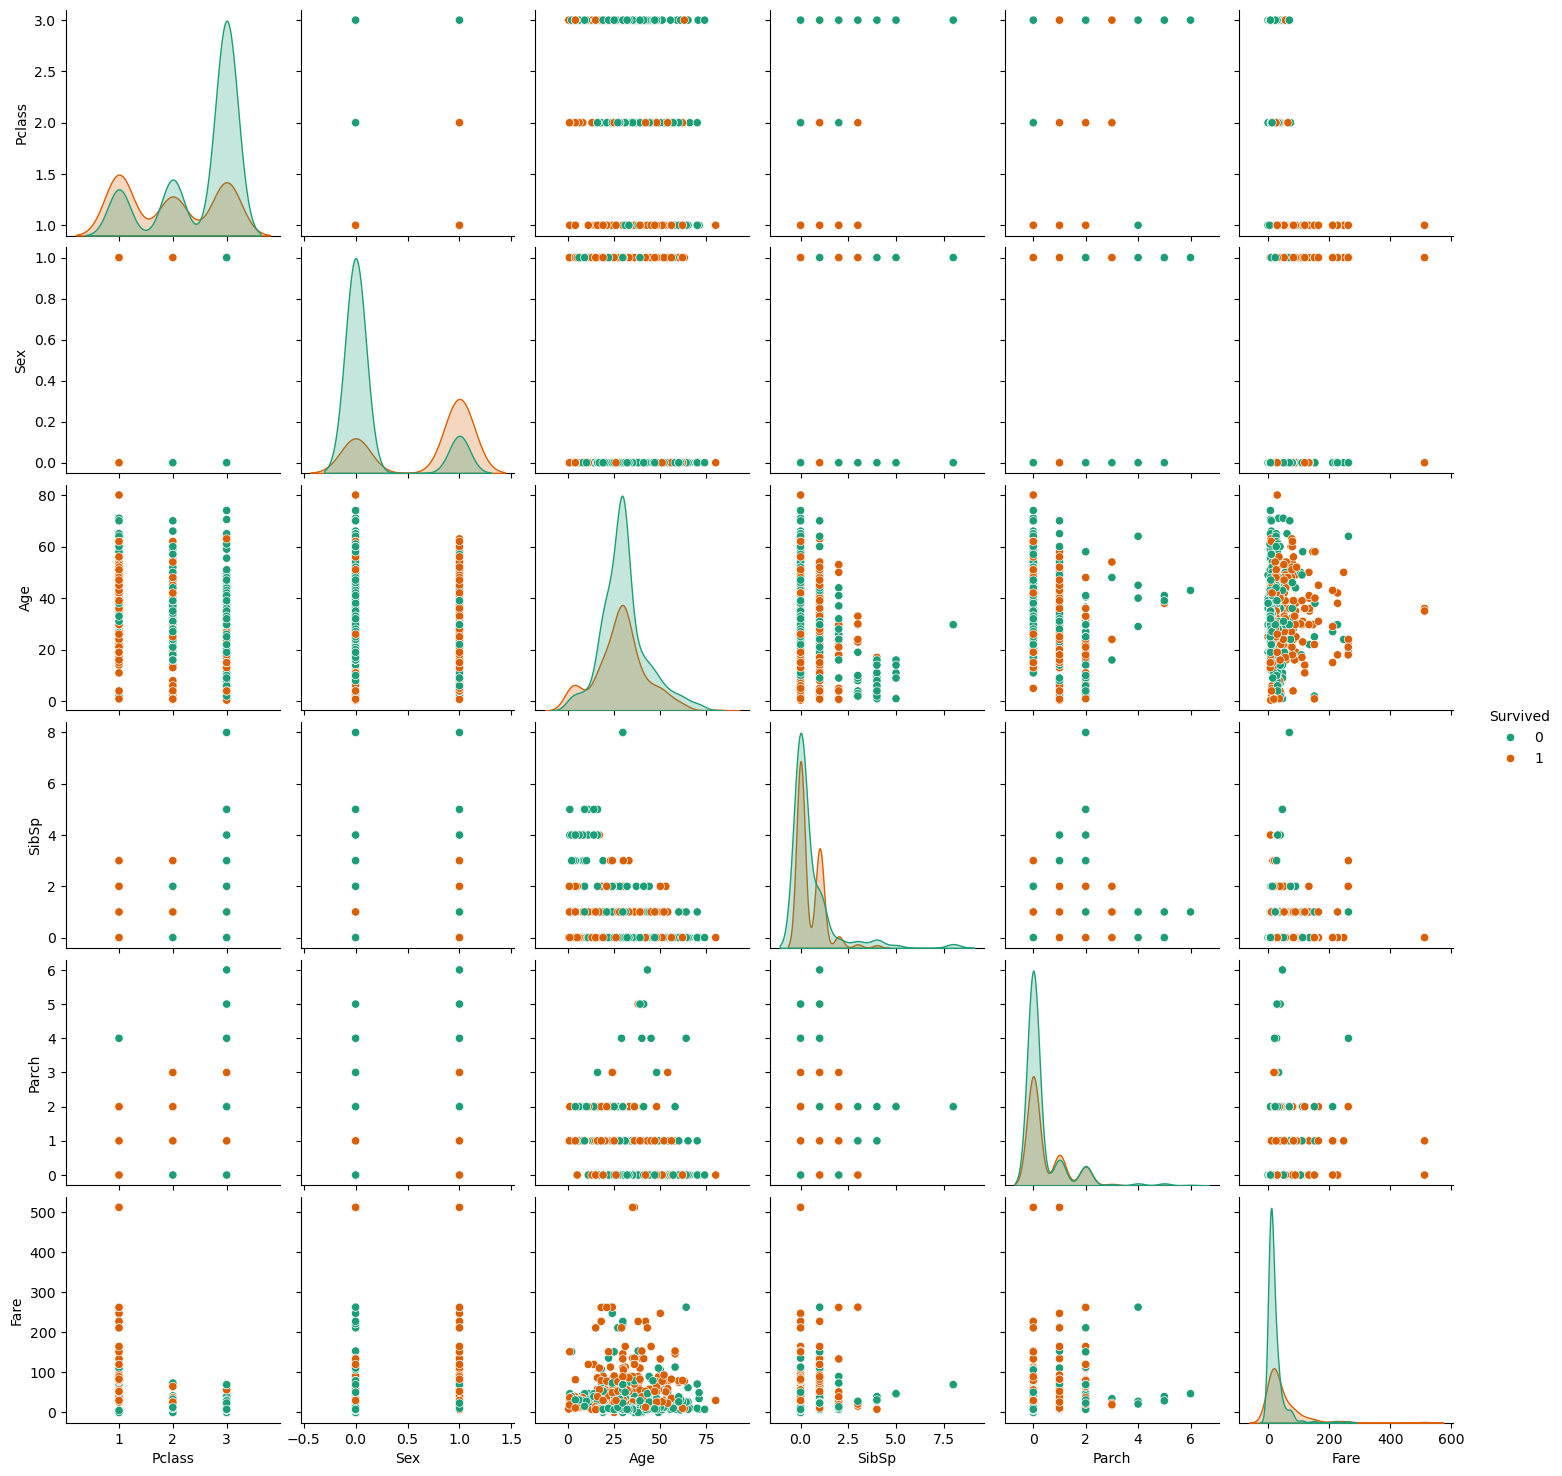

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ..................................C=0.1, gamma=0.01; total time=   0.0s
[CV] END ..................................C=0.1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
 
df_train = pd.read_csv("titanic-train.csv")

# Target Value
y_train = df_train["Survived"].values

# Encode Male/Female values
df_train["Sex"] = df_train["Sex"].map({"male": 0, "female": 1})
 
# Only keep numerical columns
df_train = df_train.drop(columns=["Survived", "PassengerId"])
df_train = df_train.select_dtypes(include=[np.number])

# Insert the mean for columns with missing data
df_train = df_train.fillna(df_train.mean())

# Show pairplot to visualize relationships between features
sns.pairplot(df_train.assign(Survived=y_train), hue="Survived", palette="Dark2")
plt.show()

# Feature values are all remaining number columns
X_train = df_train.values
 
# Standardize the feature values
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# Train the SVM on the training dataset
svc_model = SVC()
svc_model.fit(X_train, y_train)

# Create GridSearchCV and fit it to the training data 
param_grid = {'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001]}
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2)
grid.fit(X_train, y_train)

# Generate predictions
grid_predictions = grid.predict(X_train)
print(confusion_matrix(y_train, grid_predictions))
 
print("\nConfusion Matrix:")
print(confusion_matrix(y_train, grid_predictions))
 
print("\nClassification Report:")
print(classification_report(y_train, grid_predictions))

# Load the test dataset
df_test = pd.read_csv("titanic-test.csv")

# Clean using the same steps as the training set
df_test["Sex"] = df_test["Sex"].map({"male": 0, "female": 1})
# Extract PassengerId's to show results later
passenger_ids = df_test["PassengerId"].values 
df_test = df_test.drop(columns=["PassengerId"])
df_test = df_test.select_dtypes(include=[np.number])
df_test = df_test.fillna(df_test.mean())

# Standardize
X_final = scaler.transform(df_test.values)

# Generate predictions for the test set
final_predictions = grid.predict(X_final)

results = pd.DataFrame({
    "PassengerId": passenger_ids,
    "Survived": final_predictions
})

print("\nPredictions for titanic-test.csv:")
print(results.head(20))
print(f"Total predicted survived: {final_predictions.sum()}")
print(f"Total predicted did not survive: {(final_predictions == 0).sum()}")

